In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [18]:
len(words)

32033

In [19]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)

In [20]:
block_size = 3

def build_dataset(words):
    X = []
    Y = []
    
    for w in words:
        content = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(content)
            Y.append(ix)
            content = content[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [21]:
n_embd = 10
n_hidden = 200

g = torch.Generator().manual_seed(21474783647)
C = torch.randn((vocab_size,n_embd),            generator=g)
W1 = torch.randn((block_size*n_embd, n_hidden), generator=g) * (5/3) / (block_size * n_embd)**0.5
#b1 = torch.randn(n_hidden,                      generator=g) * 0.01
W2 = torch.randn((n_hidden,vocab_size),         generator=g) * 0.01
b2 = torch.randn(vocab_size,                     generator=g) * 0

bngain = torch.ones(1, n_hidden)
bnbias = torch.zeros(1, n_hidden)
bnmean_running = torch.zeros(1,n_hidden)
bnstd_running = torch.ones(1,n_hidden)

parameters = [C, W1, W2, b2, bngain, bnbias] 
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters))

12097


In [32]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    #MINIBATCH CONSTRUCT
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    #print(ix)
    Xb, Yb = Xtr[ix], Ytr[ix]

    #FOWARD PASS
    emb = C[Xb] # embeding the characters into vectors
    embcat = emb.view(emb.shape[0],-1) # concatenate vector 

    #LINEAR LAYER
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation

    #BATCH NORMALIZATION
    #-------------------------------------------------------------
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani  / bnstdi ) + bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    #-------------------------------------------------------------

    #NON-LINEARITY
    h = torch.tanh(hpreact) # hidden layer
    
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss function

    #BACKWARD PASS
    for p in parameters:
        p.grad = None
    loss.backward()

    #UPDATE
    lr = 0.1 if  i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #TRACK STATS
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    break


      0/ 200000: 3.2380


In [9]:
h.shape

torch.Size([32, 200])

In [10]:
(torch.ones(3,6) @ torch.ones(6,15))

tensor([[6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6.],
        [6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6.],
        [6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6., 6.]])

In [11]:
-torch.tensor(1/27).log()

tensor(3.2958)

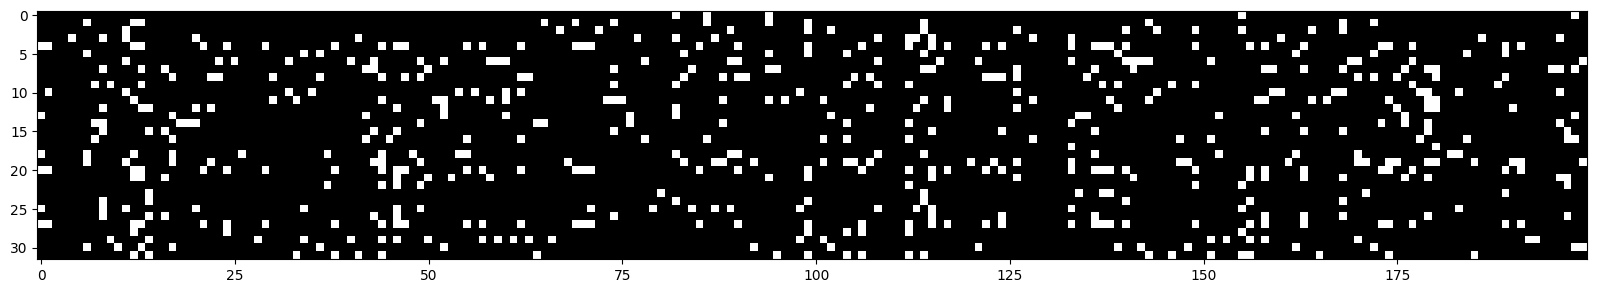

In [12]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")

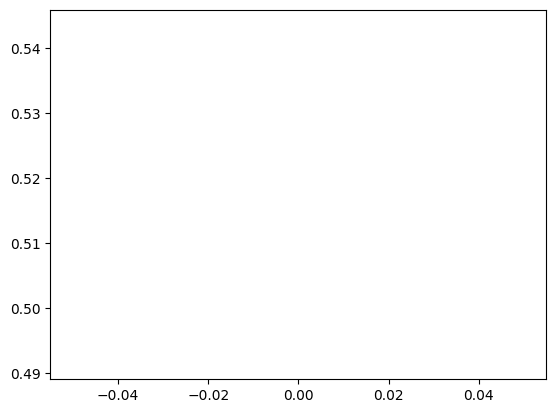

In [13]:
plt.plot(lossi)

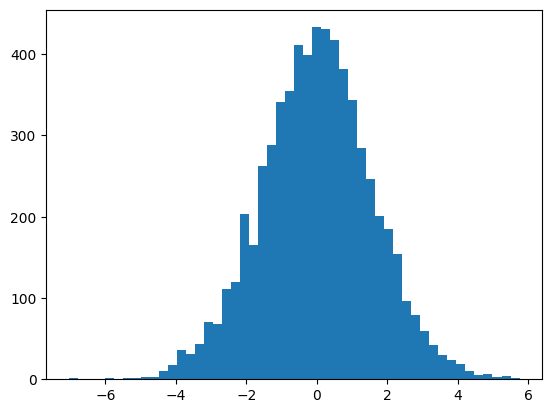

In [14]:
plt.hist(hpreact.view(-1).tolist(),50);

In [15]:
with torch.no_grad():
    emb = C[Xtr]
    embact = emb.view(emb.shape[0], -1)
    hpreact = embact @ W1 + b1
    bnmean = hpreact.mean(0,keepdim=True)
    bnstd = hpreact.std(0,keepdim=True)

NameError: name 'b1' is not defined

In [ ]:
@torch.no_grad() #disables gradient tracking
def split_loss(split):
    x,y = {
        'train':(Xtr,Ytr),
        'val':(Xdev,Ydev),
        'test':(Xte, Yte),
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1 # hidden layer pre-activation
    hpreact = bngain * ((hpreact - bnmean_running )/ bnstd_running) + bnbias
    h = torch.tanh(hpreact) # hidden layer
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        #sample from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))